# Ejercicio Titanic
## Emilio Leon y Sofía Blancas
### 16/02/2026

In [2]:
import seaborn as sns
import pandas as pd
titanic = sns.load_dataset("titanic")
import matplotlib.pyplot as plt

In [3]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
titanic.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

### Hay datoas faltantes en edad(177), en embarked(2), en deck(688), y en embark_town

### El tipo category significa que son datos que forman parte de una lista diferente para cada renglón.

### Segun info hay 15 columnas.

In [6]:
len(titanic.columns)

15

### Según info el df tiene 891 renglones.

In [7]:
len(titanic)

891

In [8]:
edad_prom = titanic["age"].mean()
print(edad_prom)

29.69911764705882


### La edad promedio de los pasajeros era de 29.2991 años. Redondeando, 30

In [9]:
max_fare = titanic["fare"].max()
print(max_fare)

512.3292


### La tarifa máxima que se pagó fue de 512 dólares.

In [10]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Se corroboran las respuestas.

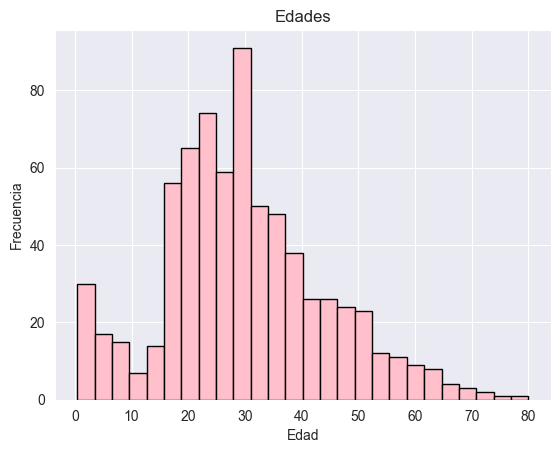

In [11]:
plt.hist(titanic["age"], bins=26, color = "pink", edgecolor = "black")
plt.title("Edades")
plt.ylabel("Frecuencia")
plt.xlabel("Edad")
plt.show()

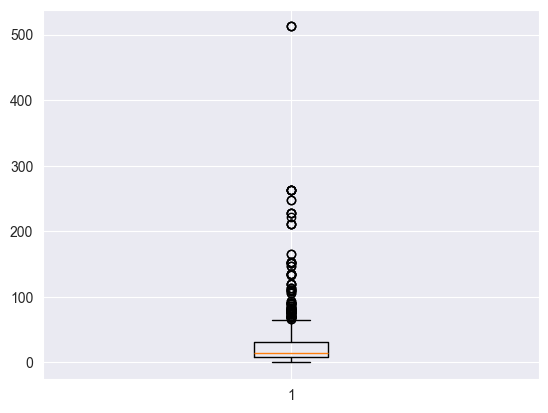

In [12]:
plt.boxplot(titanic["fare"])
plt.show()

### Sí, aparentemente hay valores atípicos.

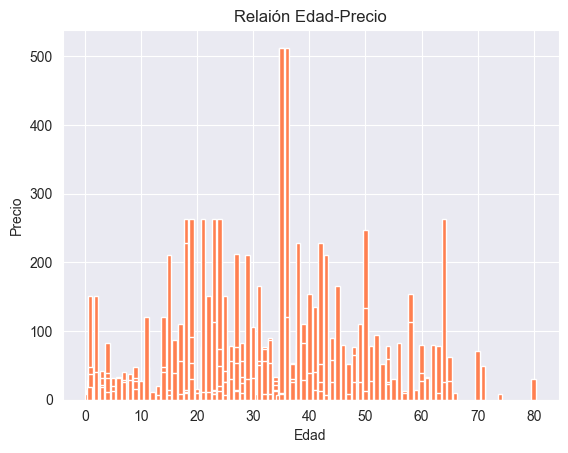

In [13]:
plt.bar(titanic["age"], titanic["fare"], color="coral")
plt.title("Relaión Edad-Precio")
plt.ylabel("Precio")
plt.xlabel("Edad")
plt.show()

### No diría que hay una relación entre la edad y el precio del boleto.

In [14]:
titanic["sex"].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [15]:
pd.crosstab(titanic["sex"], titanic["survived"])

survived,0,1
sex,,
female,81,233
male,468,109


### Se salvaron más mujeres que hombres, en una proporción más alta.

In [16]:
tot_fem = len(titanic.loc[titanic["sex"]=="female", "sex"])
print(tot_fem)

314


In [17]:
tot_mas = len(titanic.loc[titanic["sex"]=="male", "sex"])
print(tot_mas)

577


In [18]:
fem_sob = titanic.loc[(titanic["sex"]=="female")&(titanic["survived"]==1)]
fem_sob

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
874,1,2,female,28.0,1,0,24.0000,C,Second,woman,False,NaN,Cherbourg,yes,False
875,1,3,female,15.0,0,0,7.2250,C,Third,child,False,NaN,Cherbourg,yes,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
880,1,2,female,25.0,0,1,26.0000,S,Second,woman,False,NaN,Southampton,yes,False


In [19]:
fem_sob_count = len(fem_sob)
print(fem_sob_count)

233


In [20]:
mas_sob = titanic.loc[(titanic["sex"]=="male")&(titanic["survived"]==1)]
mas_sob

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
17,1,2,male,NaN,0,0,13.0000,S,Second,man,True,NaN,Southampton,yes,True
21,1,2,male,34.0,0,0,13.0000,S,Second,man,True,D,Southampton,yes,True
23,1,1,male,28.0,0,0,35.5000,S,First,man,True,A,Southampton,yes,True
36,1,3,male,NaN,0,0,7.2292,C,Third,man,True,NaN,Cherbourg,yes,True
55,1,1,male,NaN,0,0,35.5000,S,First,man,True,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
838,1,3,male,32.0,0,0,56.4958,S,Third,man,True,NaN,Southampton,yes,True
839,1,1,male,NaN,0,0,29.7000,C,First,man,True,C,Cherbourg,yes,True
857,1,1,male,51.0,0,0,26.5500,S,First,man,True,E,Southampton,yes,True
869,1,3,male,4.0,1,1,11.1333,S,Third,child,False,NaN,Southampton,yes,False


In [21]:
mas_sob_count = len(mas_sob)
print(mas_sob_count)

109
